# AI-Driven Student Performance Prediction System

## Objective:
To predict student performance using Machine Learning based on academic and behavioral factors.

In [1]:
print("Hello")

Hello


In [2]:
import pandas as pd

df = pd.read_csv("../Dataset/student_data.csv")
df.head()


,gender,study_hours,attendance,previous_score,assignments_completed,sleep_hours,internet_access,extracurricular,final_score
0,Male,5,85,78,9,7,Yes,Yes,82
1,Female,6,90,85,10,8,Yes,Yes,90
2,Male,2,60,55,5,6,No,No,58
3,Female,8,95,92,10,7,Yes,Yes,96
4,Male,4,75,70,8,6,Yes,No,74


In [3]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   gender                 10 non-null     str  
 1   study_hours            10 non-null     int64
 2   attendance             10 non-null     int64
 3   previous_score         10 non-null     int64
 4   assignments_completed  10 non-null     int64
 5   sleep_hours            10 non-null     int64
 6   internet_access        10 non-null     str  
 7   extracurricular        10 non-null     str  
 8   final_score            10 non-null     int64
dtypes: int64(6), str(3)
memory usage: 955.0 bytes


In [4]:
# Statistical Summary
df.describe()


,study_hours,attendance,previous_score,assignments_completed,sleep_hours,final_score
count,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000
mean,5.000000,78.600000,73.800000,7.90000,6.900000,77.700000
std,2.581989,15.875908,16.274042,2.18327,0.994429,16.499495
min,1.000000,50.000000,45.000000,4.00000,5.000000,48.000000
25%,3.250000,67.500000,62.500000,6.50000,6.250000,67.250000
50%,5.000000,82.500000,77.000000,8.50000,7.000000,80.500000
75%,6.750000,89.500000,84.250000,9.75000,7.750000,89.250000
max,9.000000,98.000000,95.000000,10.00000,8.000000,98.000000


In [5]:
# Missing Values
df.isnull().sum()

gender                   0
study_hours              0
attendance               0
previous_score           0
assignments_completed    0
sleep_hours              0
internet_access          0
extracurricular          0
final_score              0
dtype: int64

In [6]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   gender                 10 non-null     str  
 1   study_hours            10 non-null     int64
 2   attendance             10 non-null     int64
 3   previous_score         10 non-null     int64
 4   assignments_completed  10 non-null     int64
 5   sleep_hours            10 non-null     int64
 6   internet_access        10 non-null     str  
 7   extracurricular        10 non-null     str  
 8   final_score            10 non-null     int64
dtypes: int64(6), str(3)
memory usage: 955.0 bytes


In [7]:
# Statistical Summary
df.describe()

,study_hours,attendance,previous_score,assignments_completed,sleep_hours,final_score
count,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000
mean,5.000000,78.600000,73.800000,7.90000,6.900000,77.700000
std,2.581989,15.875908,16.274042,2.18327,0.994429,16.499495
min,1.000000,50.000000,45.000000,4.00000,5.000000,48.000000
25%,3.250000,67.500000,62.500000,6.50000,6.250000,67.250000
50%,5.000000,82.500000,77.000000,8.50000,7.000000,80.500000
75%,6.750000,89.500000,84.250000,9.75000,7.750000,89.250000
max,9.000000,98.000000,95.000000,10.00000,8.000000,98.000000


In [8]:
# Check Missing Values
df.isnull().sum()

gender                   0
study_hours              0
attendance               0
previous_score           0
assignments_completed    0
sleep_hours              0
internet_access          0
extracurricular          0
final_score              0
dtype: int64

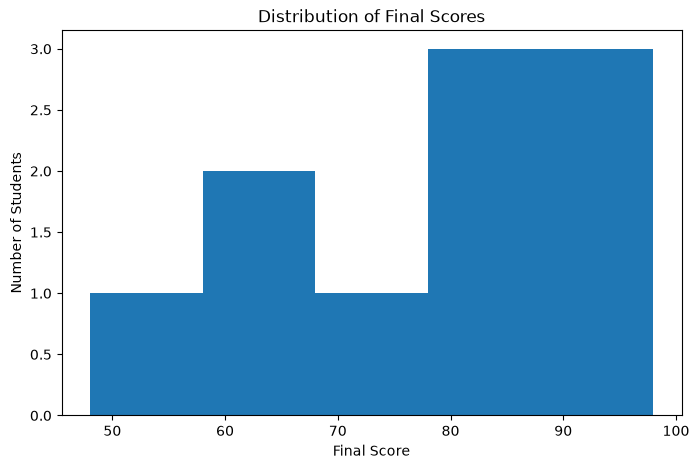

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["final_score"], bins=5)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")

plt.show()

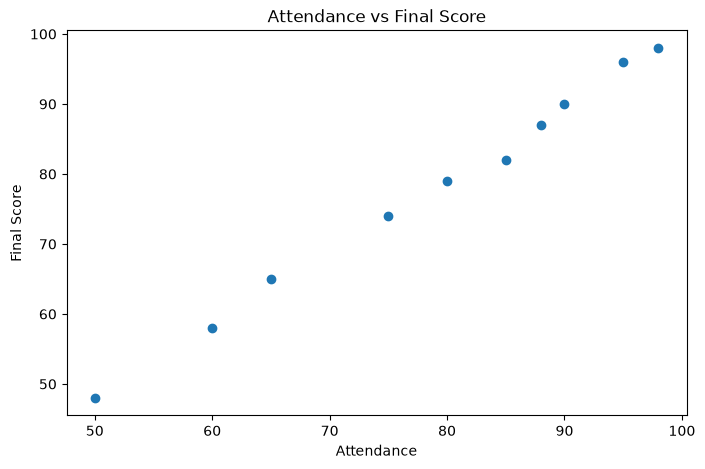

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(df["attendance"], df["final_score"])

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance")
plt.ylabel("Final Score")

plt.show()

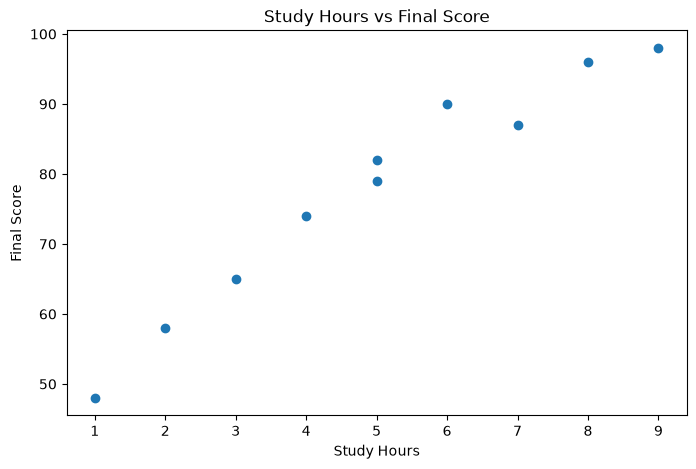

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(df["study_hours"], df["final_score"])

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

plt.show()

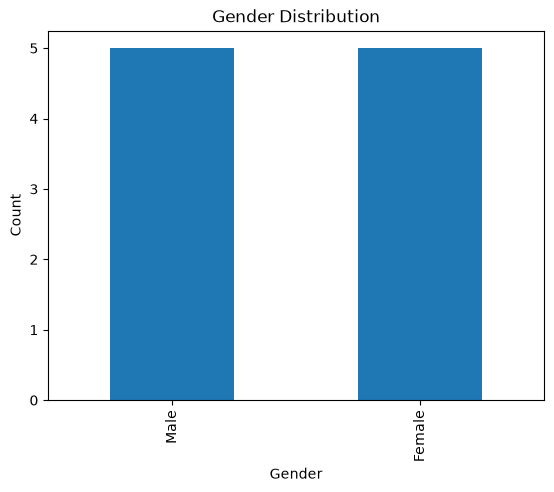

In [12]:
df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["internet_access"] = le.fit_transform(df["internet_access"])
df["extracurricular"] = le.fit_transform(df["extracurricular"])

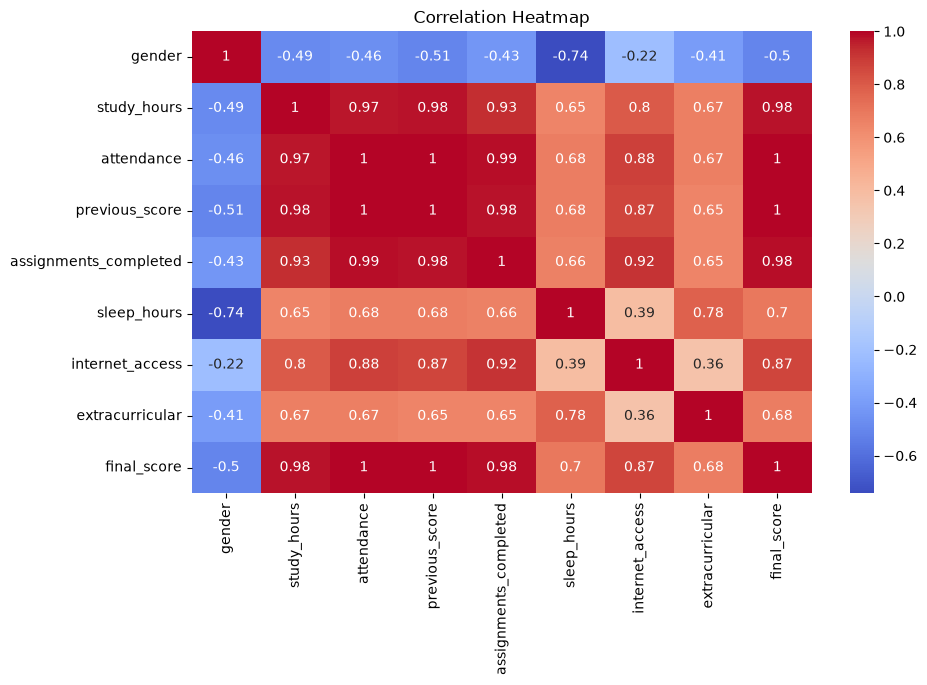

In [14]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [15]:
# Features and Target

X = df.drop("final_score", axis=1)
y = df["final_score"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (10, 8)
Target Shape: (10,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8, 8)
Testing Data: (2, 8)


In [49]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [18]:
y_pred = model.predict(X_test)

print(y_pred)

[61.93 87.79]


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))

R2 Score : 0.7744569160997733
MAE : 8.069999999999997


In [20]:
df = pd.read_csv("../Dataset/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [21]:
df = pd.read_csv("../Dataset/student_data.csv")

df.head()

,gender,study_hours,attendance,previous_score,assignments_completed,sleep_hours,internet_access,extracurricular,final_score
0,Male,5,85,78,9,7,Yes,Yes,82
1,Female,6,90,85,10,8,Yes,Yes,90
2,Male,2,60,55,5,6,No,No,58
3,Female,8,95,92,10,7,Yes,Yes,96
4,Male,4,75,70,8,6,Yes,No,74


In [22]:
df.describe()

,study_hours,attendance,previous_score,assignments_completed,sleep_hours,final_score
count,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000
mean,5.000000,78.600000,73.800000,7.90000,6.900000,77.700000
std,2.581989,15.875908,16.274042,2.18327,0.994429,16.499495
min,1.000000,50.000000,45.000000,4.00000,5.000000,48.000000
25%,3.250000,67.500000,62.500000,6.50000,6.250000,67.250000
50%,5.000000,82.500000,77.000000,8.50000,7.000000,80.500000
75%,6.750000,89.500000,84.250000,9.75000,7.750000,89.250000
max,9.000000,98.000000,95.000000,10.00000,8.000000,98.000000


In [23]:
df.columns

Index(['gender', 'study_hours', 'attendance', 'previous_score',
       'assignments_completed', 'sleep_hours', 'internet_access',
       'extracurricular', 'final_score'],
      dtype='str')

In [24]:
df = pd.read_csv("../Dataset/StudentPerformanceFactors.csv")

print(df.head())

print(df.columns)

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [25]:
import os

print(os.listdir("../Dataset"))

['StudentPerformanceFactors.csv', 'student_data.csv']


In [26]:
df = pd.read_csv("../Dataset/StudentPerformanceFactors.csv")
print(df.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [27]:
df = pd.read_csv("../Dataset/StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [29]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [30]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [31]:
print("Rows and Columns:", df.shape)

Rows and Columns: (6607, 20)


In [32]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [33]:
# Check missing values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [34]:
# Fill numerical missing values with median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\Vashu Garg\AppData\Local\Temp\ipykernel_16844\312527891.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [48]:

from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


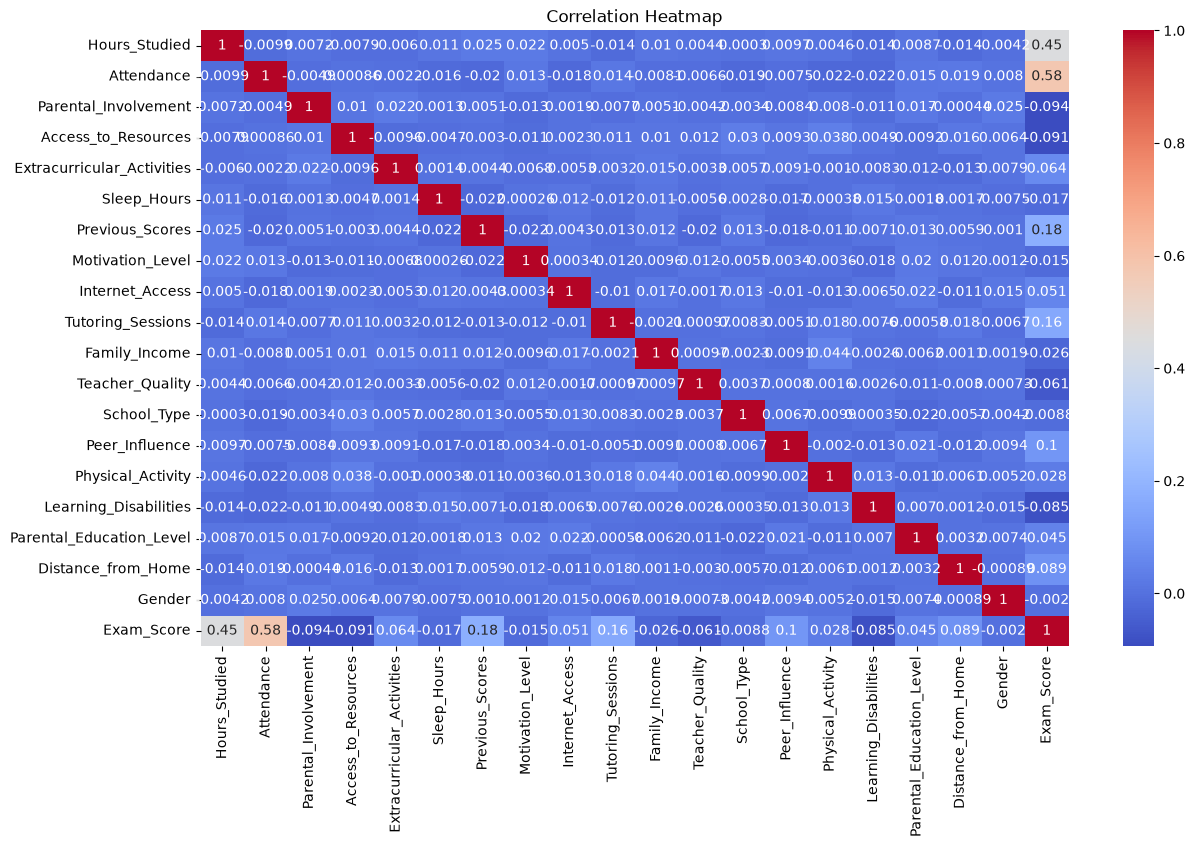

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [37]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

print(X.shape)
print(y.shape)

(6607, 19)
(6607,)


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [40]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[64.81 66.33 70.33 66.35 66.35 66.71 70.98 67.22 69.7  69.99]


In [41]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.6546399715264632
MAE: 1.1313993948562784


                       Feature  Importance
1                   Attendance    0.380088
0                Hours_Studied    0.242312
6              Previous_Scores    0.091586
9            Tutoring_Sessions    0.035263
5                  Sleep_Hours    0.030049
14           Physical_Activity    0.028412
3          Access_to_Resources    0.027855
2         Parental_Involvement    0.027454
13              Peer_Influence    0.018911
10               Family_Income    0.018383
17          Distance_from_Home    0.017268
16    Parental_Education_Level    0.016512
7             Motivation_Level    0.013064
11             Teacher_Quality    0.012332
15       Learning_Disabilities    0.009278
4   Extracurricular_Activities    0.009131
12                 School_Type    0.008634
18                      Gender    0.007435
8              Internet_Access    0.006035


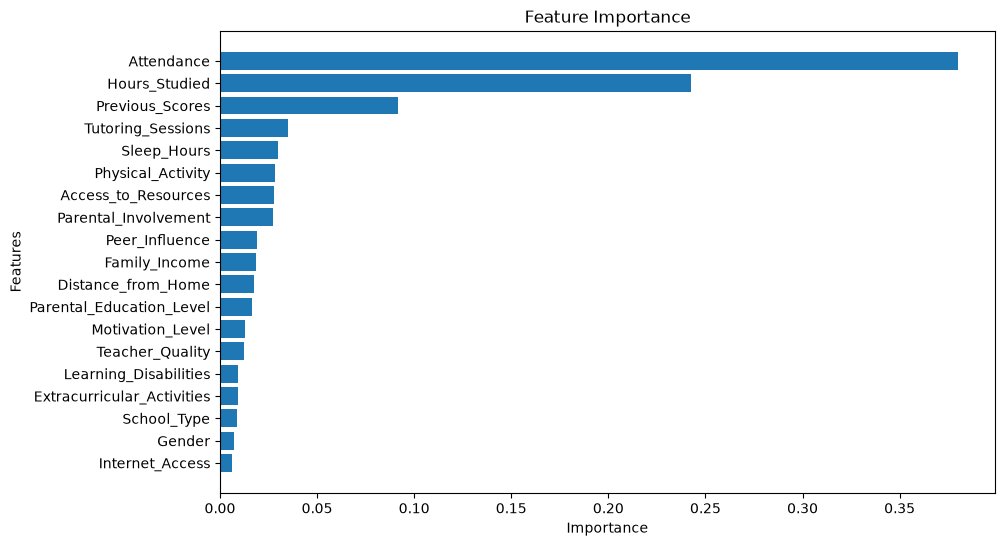

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

In [43]:
import joblib
import os

os.makedirs("../Model", exist_ok=True)

joblib.dump(model, "../Model/student_performance_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [44]:
print(X.columns)

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender'],
      dtype='str')


In [45]:
print(X.shape)

(6607, 19)


In [51]:
print(X.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [50]:
import joblib
import os


os.makedirs("../Model", exist_ok=True)

joblib.dump(model, "student_performance_model.pkl")
joblib.dump(encoders, "../Model/encoders.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [53]:
print(encoders.keys())

dict_keys([])


In [52]:
for col, encoder in encoders.items():
    print(f"\n{col}")
    print(list(encoder.classes_))

In [54]:
print(df.dtypes)

Hours_Studied                 int64
Attendance                    int64
Parental_Involvement          int64
Access_to_Resources           int64
Extracurricular_Activities    int64
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level              int64
Internet_Access               int64
Tutoring_Sessions             int64
Family_Income                 int64
Teacher_Quality               int64
School_Type                   int64
Peer_Influence                int64
Physical_Activity             int64
Learning_Disabilities         int64
Parental_Education_Level      int64
Distance_from_Home            int64
Gender                        int64
Exam_Score                    int64
dtype: object
